In [5]:
import json
import os
import subprocess
import itertools
from datetime import datetime
import pandas as pd
from pathlib import Path
import sys
import pickle as pl
import torch
import itertools
import random
import numpy as np

In [6]:
env = os.environ.copy()
env['MKL_SERVICE_FORCE_INTEL'] = '1'
env['MKL_THREADING_LAYER'] = 'GNU'
env['OMP_NUM_THREADS'] = '1'

In [7]:
# with open('results_datainfo/snli_(0.1, 0.73, 0.17)/accuracy_arr.pkl','rb') as f:
#    obj = pl.load(f)

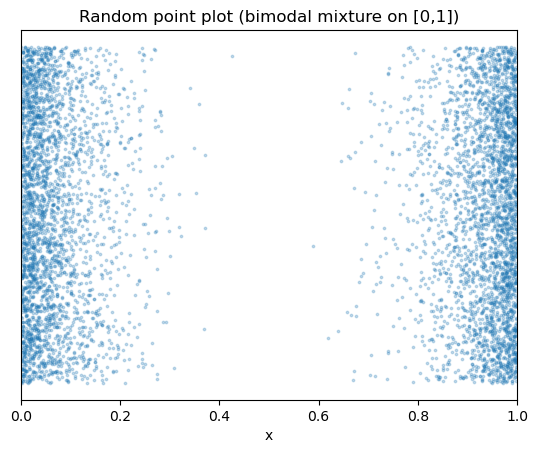

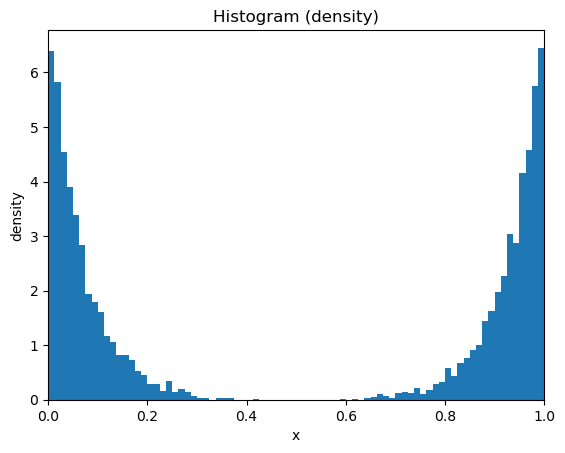

In [8]:
import random
import matplotlib.pyplot as plt

def sample_bimodal_beta(n=5000, p=0.5, a=2, b=90):
    """
    Mixture: with prob p sample Beta(a,b) (peaks near 0),
             else sample Beta(b,a) (peaks near 1).
    """
    xs = []
    for _ in range(n):
        if random.random() < p:
            xs.append(random.betavariate(a, b))
        else:
            xs.append(random.betavariate(b, a))
    return xs

# 1) sample
x = sample_bimodal_beta(n=6000, p=0.5, a=1, b=14)

# 2) "random points plot" (strip plot)
#    put points at y=0 with a tiny vertical jitter so you can see density
y = [(random.random() - 0.5) * 0.08 for _ in x]  # jitter in [-0.04, 0.04]

plt.figure()
plt.scatter(x, y, s=3, alpha=0.25)
plt.yticks([])
plt.xlim(0, 1)
plt.title("Random point plot (bimodal mixture on [0,1])")
plt.xlabel("x")
plt.show()

# 3) histogram view (often clearer)
plt.figure()
plt.hist(x, bins=80, density=True)
plt.xlim(0, 1)
plt.title("Histogram (density)")
plt.xlabel("x")
plt.ylabel("density")
plt.show()

In [9]:
# computed_vectors = [[0.3, 0.25, 0.45],
# [0.3, 0.3, 0.4],
# [0.3, 0.35, 0.35] ,
# [0.3, 0.4, 0.3]  ,
# [0.3, 0.45, 0.25] ,
# [0.25, 0.3, 0.45]  ,
# [0.35, 0.3, 0.35], 
# [0.4, 0.3, 0.3] ,
# [0.45, 0.3, 0.25] ,
# [0.25, 0.45, 0.3]  ,
# [0.35, 0.35, 0.3]  ,
# [0.45, 0.25, 0.3]]

In [10]:
import re 
def parse_proportion_from_filename(filename):
    """Extract proportion array from filename like 'ag_news_6e-06_[0.1, 0.3, 0.3, 0.3].json'"""
    match = re.search(r'[\[\(]\s*([0-9eE+\-.,\s]+)\s*[\]\)]', filename)
    if match:
        arr = [float(x) for x in match.group(1).split(",") if x.strip()]
        return arr
    return None


def load_experiment_data(dataset_name,interpolation_name,base_dir):
    """
    Load all experiment results with their proportions.
    
    Args:
        base_dir: Path to directory containing experiment folders
        
    Returns:
        list: List of dicts with keys 'proportions', 'alignment_matrix', 'labels', 'output_dir'
    """
    base_path = Path(base_dir)
    
    # Find all directories that match the pattern
    all_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.startswith(dataset_name) and interpolation_name in d.name]
    
    print(f"Scanning {len(all_dirs)} directories...")
    
    proportion_arr = []
    for output_dir in all_dirs:
        # Try to parse proportions from directory name
        proportion = parse_proportion_from_filename(output_dir.name)
        proportion_arr.append(proportion)
    return proportion_arr

In [11]:
import math

In [12]:
def generate_vectors(dataset_name,interpolation_name,base_dir,num_classes,no_of_examples):
    
    proportion_arr = load_experiment_data(dataset_name,interpolation_name,base_dir)
    vectors = []
    seen = set()  # Track unique combinations using sorted tuples
    indices = list(range(num_classes))
    
    for i in range(no_of_examples):
        
        v = [ round(sample_bimodal_beta(n=1, p=0.5, a=2, b=10)[0],2) for _ in range(num_classes)]
        # v = [ round(random.uniform(0,1),2) for _ in range(num_classes)]
        sum_v = float(sum(v))
        v = [   round(i/sum_v ,2) for i in v]
    
        # Check if this combination (in sorted form) already exists
        v = tuple(v)
        if v not in seen and list(v) not in proportion_arr and sum(v) == 1:
            seen.add(v)
            vectors.append(v)

    # print(f"Total unique combinations: {len(vectors)}")
    # for i, v in enumerate(vectors, 1):
    #     print(f"{i:2d}. {v}  (sum = {sum(v):.2f})")
        
    return vectors

In [13]:
def generate_vectors(dataset_name, interpolation_name, base_dir, num_classes, no_of_examples, num_bins):
    """
    Generate proportions with uniform deviation distribution, excluding existing ones
    
    Args:
        dataset_name: Dataset name for loading existing proportions
        interpolation_name: Interpolation method name
        base_dir: Base directory containing experiment results
        num_classes: Number of classes
        no_of_examples: Number of proportion vectors to generate
        num_bins: Number of deviation bins for uniform distribution (default: 10)
    
    Returns:
        List of proportion tuples with uniform deviation distribution
    """
    
    # Load existing proportions
    proportion_arr = load_experiment_data(dataset_name, interpolation_name, base_dir)
    
    balanced = 1.0 / num_classes
    vectors = []
    seen = set(tuple(p) for p in proportion_arr if p is not None)  # Track existing
    
    # Phase 1: Learn deviation range (generate 50 samples)
    learning_samples = []
    attempts = 0
    learning_size = min(50, no_of_examples)  # Don't learn more than needed
    
    while len(learning_samples) < learning_size and attempts < 500:
        attempts += 1
        v = [round(sample_bimodal_beta(n=1, p=0.5, a=2, b=10)[0], 2) for _ in range(num_classes)]
        sum_v = sum(v)
        v = [round(i/sum_v, 2) for i in v]
        v = tuple(v)
        
        if sum(v) == 1.0 and v not in seen and min(v) >= 0.05:
            dev = sum(abs(x - balanced) for x in v)
            learning_samples.append((v, dev))
            seen.add(v)
    
    if len(learning_samples) < 10:
        print(f"⚠️ Warning: Only generated {len(learning_samples)} learning samples")
        return [v for v, _ in learning_samples]
    
    # Create bins for uniform deviation distribution
    deviations = [d for _, d in learning_samples]
    dev_min, dev_max = min(deviations), max(deviations)
    bins = np.linspace(dev_min, dev_max, num_bins + 1)
    target_per_bin = no_of_examples // num_bins
    bin_counts = [0] * num_bins
    
    print(f"📊 Deviation bins: {num_bins} bins from {dev_min:.3f} to {dev_max:.3f}")
    print(f"   Target per bin: {target_per_bin}")
    
    # Add learning samples to bins
    for v, dev in learning_samples:
        if len(vectors) >= no_of_examples:
            break
        bin_idx = min(num_bins - 1, max(0, np.searchsorted(bins[:-1], dev, side='right') - 1))
        if bin_counts[bin_idx] < target_per_bin:
            vectors.append(v)
            bin_counts[bin_idx] += 1
    
    # Phase 2: Fill under-represented bins
    attempts = 0
    max_attempts = no_of_examples * 100
    
    while len(vectors) < no_of_examples and attempts < max_attempts:
        attempts += 1
        
        # Find most under-represented bin
        min_count = min(bin_counts)
        target_bin = bin_counts.index(min_count) if min_count < target_per_bin else None
        
        # Generate sample (target specific bin if under-represented)
        if target_bin is not None:
            # Adjust sampling to target this deviation range
            target_dev = (bins[target_bin] + bins[target_bin + 1]) / 2
            
            # Adaptive sampling based on target deviation
            if target_dev < 0.2:
                a, b = 5, 20  # Low deviation (more balanced)
            elif target_dev < 0.5:
                a, b = 2, 10  # Medium deviation
            else:
                a, b = 1, 5   # High deviation (more imbalanced)
        else:
            a, b = 2, 10  # Default
        
        v = [round(sample_bimodal_beta(n=1, p=0.5, a=a, b=b)[0], 2) for _ in range(num_classes)]
        sum_v = sum(v)
        v = [round(i/sum_v, 2) for i in v]
        v = tuple(v)
        
        # Validate
        if sum(v) != 1.0 or v in seen or min(v) < 0.05:
            continue
        
        # Check deviation and add to appropriate bin
        dev = sum(abs(x - balanced) for x in v)
        bin_idx = min(num_bins - 1, max(0, np.searchsorted(bins[:-1], dev, side='right') - 1))
        
        if bin_counts[bin_idx] < target_per_bin or target_bin is None:
            vectors.append(v)
            seen.add(v)
            bin_counts[bin_idx] += 1
    
    print(f"✅ Generated {len(vectors)}/{no_of_examples} proportions")
    print(f"   Deviation range: [{dev_min:.3f}, {dev_max:.3f}]")
    print(f"   Bin distribution: {bin_counts}")
    
    return vectors

In [14]:
# def generate_vectors(dataset_name,interpolation_name,base_dir,step,fixed_value,max_value,min_value,num_classes):
    
#     proportion_arr = load_experiment_data(dataset_name,interpolation_name,base_dir)
#     remaining_sum = 1.0 - fixed_value
    
#     values = [round(step * i, 2) for i in range( math.ceil(min_value/step),   int(max_value/step) + 1)]
#     print(values)
#     vectors = []
#     seen = set()  # Track unique combinations using sorted tuples
#     num_classes = 3
#     indices = list(range(num_classes))

#     for fixed_idx in indices:  # Which position to fix at 0.3
#         for x in values:
#             y = round(remaining_sum - x, 2)
            
#             # Only include if y is valid (0.05 <= y <= 0.65)
#             if min_value <= y <= max_value:
#                 v = [0.0] * num_classes
#                 v[fixed_idx] = fixed_value
                
#                 # Fill other two positions
#                 other_indices = [idx for idx in indices if idx != fixed_idx]
#                 v[other_indices[0]] = x
#                 v[other_indices[1]] = y
                
#                 # Check if this combination (in sorted form) already exists
#                 v = tuple(v)
#                 if v not in seen and list(v) not in proportion_arr:
#                     seen.add(v)
#                     vectors.append(v)

#     # print(f"Total unique combinations: {len(vectors)}")
#     # for i, v in enumerate(vectors, 1):
#     #     print(f"{i:2d}. {v}  (sum = {sum(v):.2f})")
        
#     return vectors

In [15]:
step = 0.07
fixed_value = 0.3  # One class fixed at this 
max_value = 0.65
min_value = 0.05
fixed_values_arr = [0.3,0.35,0.4]

In [16]:
# vectors_set = set()
# for fixed_value in fixed_values_arr:
#     vectors_set.update(generate_vectors('snli','linear','./results1',step,fixed_value,max_value,min_value,num_classes=3))

In [17]:
vectors_set = set()
num_classes = 4
dataset_name = 'ag_news'
base_dir = "./results_align_matrix" + "_" + dataset_name
interpolation = "linear"
# for interpolation in ['linear','model_baseline','slerp','ties']:
vectors_set.update(generate_vectors(dataset_name ,interpolation,base_dir,num_classes,800,30))

Scanning 36 directories...
📊 Deviation bins: 30 bins from 0.020 to 0.920
   Target per bin: 26
✅ Generated 800/800 proportions
   Deviation range: [0.020, 0.920]
   Bin distribution: [26, 26, 28, 26, 26, 26, 26, 26, 27, 26, 26, 26, 30, 26, 26, 26, 26, 26, 27, 27, 34, 26, 26, 27, 27, 26, 26, 26, 27, 26]


In [18]:
vectors_list = list(vectors_set)

In [19]:
# def compute_baseline_mae_simple(proportions_list, num_classes):
#     """
#     Compute baseline MAE when predicting uniform proportions (1/num_classes).
    
#     Args:
#         proportions_list: List of proportion arrays
#         num_classes: Number of classes
    
#     Returns:
#         Average MAE across all configurations
#     """
#     baseline_pred = 1.0 / num_classes
    
#     mae_list = []
#     for props in proportions_list:
#         # MAE = mean(|true - predicted|) across all classes
#         mae = np.mean([abs(p - baseline_pred) for p in props])
#         mae_list.append(mae)
    
#     avg_mae = np.mean(mae_list)
#     std_mae = np.std(mae_list)
    
#     print(f"Baseline MAE (predicting uniform {baseline_pred:.3f} for all classes):")
#     print(f"  Average MAE: {avg_mae:.6f} ± {std_mae:.6f}")
#     print(f"  Configs: {len(proportions_list)}")
    
#     return avg_mae, std_mae
# compute_baseline_mae_simple(vectors_list, 3)

In [20]:
# from datasets import load_dataset
# dataset = load_dataset('yelp/yelp_review_full')

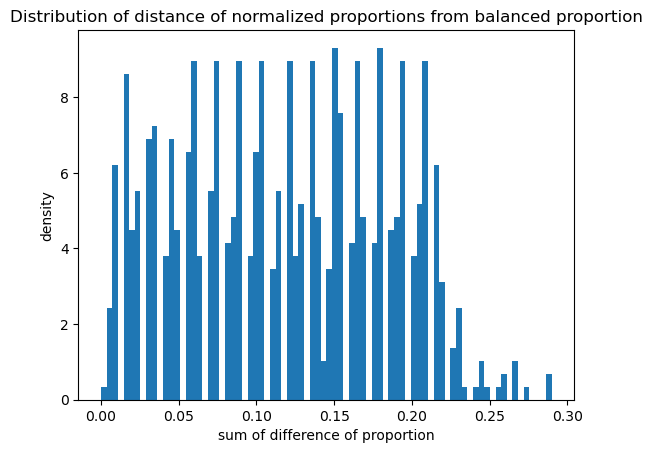

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def distance_of_proportions(X, no_of_classes, ddof=0):
    """
    X: array shape (N,3) with values in [0,1]
    returns:
      P: normalized proportions, shape (N,3)
    """
    X = np.asarray(X, dtype=float)
    l1 = np.mean(np.abs(X - float(1/no_of_classes)), axis=1)
    return l1


l1 = distance_of_proportions(vectors_list, 4, ddof=0)

plt.figure()
plt.hist(l1, bins=80, density=True)  # density=True => area under histogram = 1
plt.xlabel("sum of difference of proportion")
plt.ylabel("density")
plt.title("Distribution of distance of normalized proportions from balanced proportion")
plt.show()

In [35]:
# 0.000006 - stable learning rate

parameter_grid_2 = {
    "n_total": [5000],
    "n_finetune": [2500],
    "model_name": ["bert-base-uncased"],
    "max_length": [256],
    "num_labels": [4],
    "batch_size": [32],
    "learning_rate": [0.000006],
    "num_epochs": [9],
    "K": [15],
    "lambda_min": [0.05],
    "lambda_max": [0.95],
    "interpolations": [["linear","model_baseline","slerp","ties"],],
    "optimizer": ["Adam"],
    "dataset": ["ag_news"],
    "proportionArr": vectors_list,
    "finetuning_source": ["original"]
}

# 0.000006, 0.00001

# # to be fixed
# [0.1,0.7,0.1,0.1] 

# # done 
# [0.25,0.25,0.25,0.25]
# [0.3,0.1,0.3,0.3]


    # "learning_rate": [0.000006,0.000003],



In [36]:
# parameter_grid_3 = {
#     "n_total": [5000],
#     "n_finetune": [2500],
#     "model_name": ["bert-base-uncased"],
#     "max_length": [256],
#     "num_labels": [5],
#     "batch_size": [32],
#     "learning_rate": [0.001,0.003],
#     "num_epochs": [2],
#     "K": [15],
#     "lambda_min": [0.05],
#     "lambda_max": [0.95],
#     "interpolation": ["linear"],
#     "optimizer": ["Adam"],
#     "dataset": ["yelp_review_full"],
#     "proportionArr": [[0.27,0.1,0.27,0.1,0.26],]
    
    
    # # to be fixed
    # [0.1,0.1,0.6,0.1,0.1]
    # [0.05,0.1,0.05,0.7,0.1]
    
    
    # # done 
    # [0.2,0.2,0.2,0.2,0.2]


In [37]:
parameter_grids = []
parameter_grids.append(parameter_grid_2)
# parameter_grids.append(parameter_grid_3)

In [38]:
# Or define specific combinations
specific_configs = []

In [43]:
def generate_all_combinations(param_grid):
    keys = param_grid.keys()
    values = param_grid.values()
    combinations = []
    
    for combination in itertools.product(*values):
        config = dict(zip(keys, combination))
        combinations.append(config)
    
    return combinations

def create_config_file(config, experiment_path):
    config['experiment_name'] = experiment_path
    config_path = experiment_path + ".json"
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print(f"Created config file: {config_path}")

def run_experiment(config, experiment_name):
    try:
        # Create config file
        create_config_file(config, f"{experiment_name}")
        
        print(f"\nRunning experiment: {experiment_name}")
        print(f"Config: {config}")
        
        # result = subprocess.run([sys.executable, "agnews_sample_hacking_last_layer.py", f"{experiment_name}.json"], capture_output=True, text=True,shell=True)
        # result = subprocess.call([sys.executable, "agnews_sample_hacking_last_layer.py", f"{experiment_name}.json"],env=env)
        result = subprocess.call([sys.executable, "domain_distribution.py", f"{experiment_name}.json"],env=env)

        
        if result == 0:
            print(f"✅ Experiment {experiment_name} completed successfully")
        else:
            print(f"❌ Experiment {experiment_name} failed")
            # print("Error:", result.stderr)
        
        return {
            "experiment_name": experiment_name,
            "config": config,
            "success": result == 0,
            # "stdout": result.stdout,
            # "stderr": result.stderr
        }
        
    except Exception as e:
        print(f"❌ Exception in {experiment_name}: {str(e)}")
        return {
            "experiment_name": experiment_name,
            "config": config,
            "success": False,
            "error": str(e)
        }

In [44]:
configs_to_run = generate_all_combinations(parameter_grids[0])
len(configs_to_run)

800

In [45]:
configs_to_run[0]

{'n_total': 5000,
 'n_finetune': 2500,
 'model_name': 'bert-base-uncased',
 'max_length': 256,
 'num_labels': 4,
 'batch_size': 32,
 'learning_rate': 6e-06,
 'num_epochs': 9,
 'K': 15,
 'lambda_min': 0.05,
 'lambda_max': 0.95,
 'interpolations': ['linear', 'model_baseline', 'slerp', 'ties'],
 'optimizer': 'Adam',
 'dataset': 'ag_news',
 'proportionArr': (0.13, 0.45, 0.06, 0.36),
 'finetuning_source': 'original'}

In [47]:
# Choose experiment mode
USE_GRID_SEARCH = True # Set to True for grid search, False for specific configs

if USE_GRID_SEARCH:
    for parameter_grid in parameter_grids:
        configs_to_run = generate_all_combinations(parameter_grid)
        print(f"Total configurations to run: {len(configs_to_run)}")
        
        # Run all experiments
        results = []
        for i, config in enumerate(configs_to_run):
            experiment_name = f"{config['dataset']}_{config['proportionArr']}"
            # experiment_name = f"yelp_review_{config['proportionArr']}"
            result = run_experiment(config, experiment_name)
            results.append(result)

        # Summary
        successful = sum(1 for r in results if r["success"])
        print(f"\n{'='*50}")
        print(f"EXPERIMENT SUMMARY")
        print(f"{'='*50}")
        print(f"Total experiments: {len(results)}")
        print(f"Successful: {successful}")
        print(f"Failed: {len(results) - successful}")
        
else:
    configs_to_run = specific_configs

Total configurations to run: 800
Created config file: ag_news_(0.13, 0.45, 0.06, 0.36).json

Running experiment: ag_news_(0.13, 0.45, 0.06, 0.36)
Config: {'n_total': 5000, 'n_finetune': 2500, 'model_name': 'bert-base-uncased', 'max_length': 256, 'num_labels': 4, 'batch_size': 32, 'learning_rate': 6e-06, 'num_epochs': 9, 'K': 15, 'lambda_min': 0.05, 'lambda_max': 0.95, 'interpolations': ['linear', 'model_baseline', 'slerp', 'ties'], 'optimizer': 'Adam', 'dataset': 'ag_news', 'proportionArr': (0.13, 0.45, 0.06, 0.36), 'finetuning_source': 'original', 'experiment_name': 'ag_news_(0.13, 0.45, 0.06, 0.36)'}


2026-03-25 11:05:24.219576: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 11:05:24.236916: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-25 11:05:24.236941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-25 11:05:24.237634: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-25 11:05:24.240688: I tensorflow/core/platform/cpu_feature_guar

✓ Mergekit imported successfully
Loading configuration from: ag_news_(0.13, 0.45, 0.06, 0.36).json
✓ Configuration loaded successfully

Output directory created: ag_news_(0.13, 0.45, 0.06, 0.36)

Full training set size: 120000
Selected subset D with 5000 samples
Label idx: 0
325
Label idx: 1
1125
Label idx: 2
150
Label idx: 3
900
Size of the computed finetuning set: 2500 

✓ Dataset info saved to ag_news_(0.13, 0.45, 0.06, 0.36)/dataset_info.json


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1/9:   0%|          | 0/3750 [00:00<?, ?it/s]/home/aditya/miniconda3/envs/myenv/lib/python3.10/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



STEP 3: Fine-tuning on D' to Create Expert Model (θ_exp)
Fine-tuning configuration:
  Learning rate: 6e-06
  Batch size: 32
  Epochs: 9
  Training samples: 2500
  Batches per epoch: 3750
Batch Interval: 2109
torch.Size([32, 256])
torch.Size([32, 256])
torch.Size([32])


...

torch.Size([32, 256])
torch.Size([32, 256])
torch.Size([32])


Epoch 1/9:   1%|▏         | 48/3750 [00:14<18:37,  3.31it/s, loss=1.23]

torch.Size([32, 256])
torch.Size([32, 256])
torch.Size([32])


Epoch 1/9:   1%|▏         | 48/3750 [00:14<19:08,  3.22it/s, loss=1.23]
Traceback (most recent call last):
  File "/home/aditya/hack_model/domain_distribution.py", line 143, in <module>
    f1.finetune_base(exp_model,output_dir,eval_size)
  File "/home/aditya/hack_model/finetuning.py", line 125, in finetune_base
    accuracy_arr = self.train_model(theta_exp_model,output_dir,eval_size,optimizer)
  File "/home/aditya/hack_model/finetuning.py", line 56, in train_model
    loss.backward()
  File "/home/aditya/miniconda3/envs/myenv/lib/python3.10/site-packages/torch/_tensor.py", line 648, in backward
    torch.autograd.backward(
  File "/home/aditya/miniconda3/envs/myenv/lib/python3.10/site-packages/torch/autograd/__init__.py", line 353, in backward
    _engine_run_backward(
  File "/home/aditya/miniconda3/envs/myenv/lib/python3.10/site-packages/torch/autograd/graph.py", line 824, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run

KeyboardInterrupt: 

In [ ]:
# When a parent process starts a child process via subprocess, the two are separate entities with their own memory space.
# The parent process is not notified in real-time about the filesystem modifications the child process is making.